In [2]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [1]:
import pandas as pd
import seaborn as sns

# Cargar el dataset de Iris desde seaborn
iris = sns.load_dataset('iris')

# Seleccionar solo las columnas numéricas para la correlación (por ejemplo, las dimensiones de los sépalos y pétalos)
data = iris.drop(columns='species')

# Calcular la correlación de Pearson
pearson_corr = data.corr(method='pearson')

# Calcular la correlación de Spearman
spearman_corr = data.corr(method='spearman')

# Calcular la correlación de Kendall
kendall_corr = data.corr(method='kendall')

# Mostrar las correlaciones
print("Correlación de Pearson:\n", pearson_corr)
print("\nCorrelación de Spearman:\n", spearman_corr)
print("\nCorrelación de Kendall:\n", kendall_corr)


Correlación de Pearson:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000

Correlación de Spearman:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.166778      0.881898     0.834289
sepal_width      -0.166778     1.000000     -0.309635    -0.289032
petal_length      0.881898    -0.309635      1.000000     0.937667
petal_width       0.834289    -0.289032      0.937667     1.000000

Correlación de Kendall:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.076997      0.718516     0.655309
sepal_width      -0.076997     1.000000     -0.185994    -0.157126
petal_length      0.718516    -0.185994      1.0000

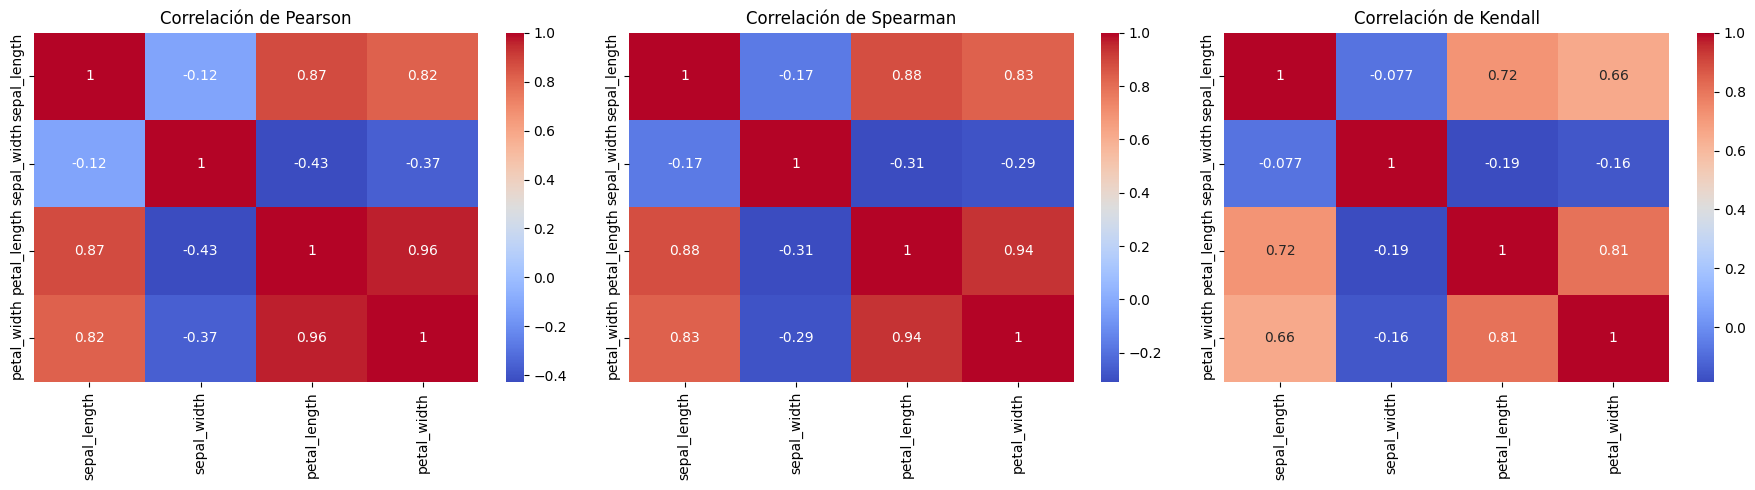

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset de Iris
iris = sns.load_dataset('iris')
data = iris.drop(columns='species')

# Calcular las correlaciones de Pearson, Spearman y Kendall
pearson_corr = data.corr(method='pearson')
spearman_corr = data.corr(method='spearman')
kendall_corr = data.corr(method='kendall')

# Configurar los subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap para Pearson
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlación de Pearson')

# Heatmap para Spearman
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlación de Spearman')

# Heatmap para Kendall
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlación de Kendall')

# Mostrar el gráfico
plt.tight_layout()
plt.show()


# RL


## regresor logistico simple

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Cargar el dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Elegimos solo dos clases: setosa (0) y versicolor (1)
mask = y < 2
X = X[mask][:, :2]  # Solo usamos las primeras 2 características
y = y[mask]

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Inicialización de pesos y bias
W = np.zeros(X.shape[1])  # pesos iniciales
b = 0                     # sesgo

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Función de predicción
def predict(X):
    z = np.dot(X, W) + b
    return sigmoid(z)

# Función de pérdida (binary cross-entropy)
def loss(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))

# Entrenamiento por gradiente descendente
lr = 0.1
epochs = 1000

for epoch in range(epochs):
    y_pred = predict(X_train)
    error = y_pred - y_train
    grad_W = np.dot(X_train.T, error) / len(y_train)
    grad_b = np.mean(error)
    W -= lr * grad_W
    b -= lr * grad_b

# Predicciones finales (umbral 0.5)
y_pred_test = predict(X_test) > 0.5
accuracy = np.mean(y_pred_test == y_test)
print("Exactitud (desde la matemática):", accuracy)

Exactitud (desde la matemática): 1.0


## desde la libreria

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Usamos los mismos datos X_train, y_train
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)
print("Exactitud (con sklearn):", accuracy_score(y_test, y_pred_sklearn))


Exactitud (con sklearn): 1.0


# KNN

## math

In [9]:
from collections import Counter

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []
    for x in X_test:
        distances = [euclidean_distance(x, x_train) for x_train in X_train]
        k_indices = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_indices]
        most_common = Counter(k_labels).most_common(1)
        predictions.append(most_common[0][0])
    return np.array(predictions)

# Predecir
y_pred_knn = knn_predict(X_train, y_train, X_test, k=3)
acc_knn = np.mean(y_pred_knn == y_test)
print("Exactitud (KNN desde cero):", acc_knn)


Exactitud (KNN desde cero): 1.0


In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
y_pred_knn_sklearn = knn_model.predict(X_test)

print("Exactitud (KNN con sklearn):", accuracy_score(y_test, y_pred_knn_sklearn))


Exactitud (KNN con sklearn): 1.0


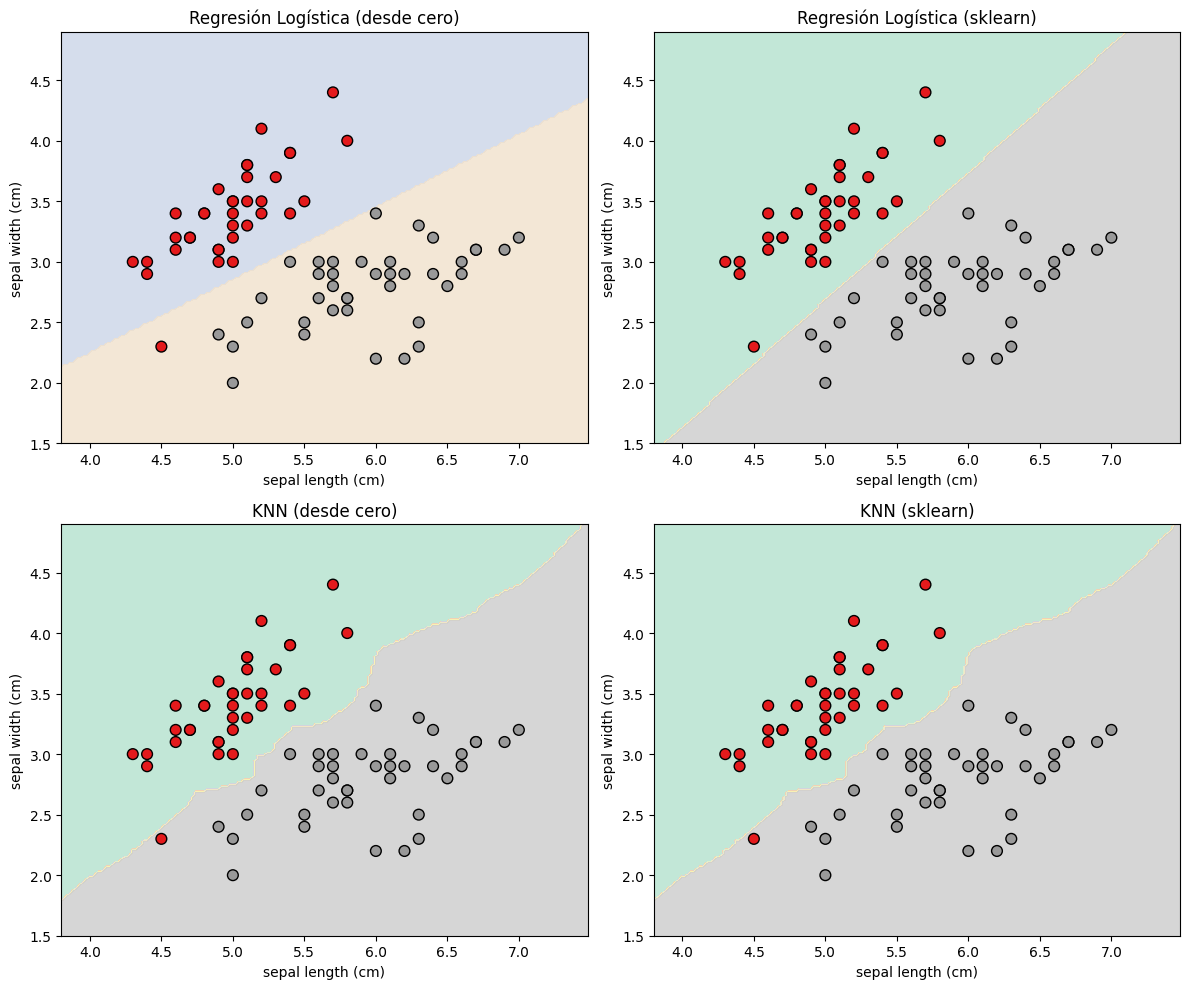

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Cargar y preparar los datos
iris = datasets.load_iris()
X = iris.data[iris.target < 2][:, :2]  # Solo setosa y versicolor, y 2 features
y = iris.target[iris.target < 2]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ---------------------
# Regresión Logística desde cero
# ---------------------
W = np.zeros(X.shape[1])
b = 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_logreg_math(X):
    return sigmoid(np.dot(X, W) + b)

# Entrenamiento
lr = 0.1
epochs = 1000
for _ in range(epochs):
    y_pred = predict_logreg_math(X_train)
    error = y_pred - y_train
    W -= lr * np.dot(X_train.T, error) / len(y_train)
    b -= lr * np.mean(error)

# ---------------------
# KNN desde cero
# ---------------------
from collections import Counter

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []
    for x in X_test:
        distances = [euclidean_distance(x, x_train) for x_train in X_train]
        k_indices = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_indices]
        most_common = Counter(k_labels).most_common(1)
        predictions.append(most_common[0][0])
    return np.array(predictions)

# ---------------------
# Modelos de sklearn
# ---------------------
logreg_sklearn = LogisticRegression()
logreg_sklearn.fit(X_train, y_train)

knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_train, y_train)

# ---------------------
# Grilla para visualizar fronteras
# ---------------------
h = .02
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predicciones para cada modelo
Z_logreg_math = predict_logreg_math(grid) > 0.5
Z_logreg_sklearn = logreg_sklearn.predict(grid)
Z_knn_math = knn_predict(X_train, y_train, grid, k=3)
Z_knn_sklearn = knn_sklearn.predict(grid)

# ---------------------
# Plot
# ---------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

titles = [
    "Regresión Logística (desde cero)",
    "Regresión Logística (sklearn)",
    "KNN (desde cero)",
    "KNN (sklearn)"
]
Zs = [Z_logreg_math, Z_logreg_sklearn, Z_knn_math, Z_knn_sklearn]

for ax, Z, title in zip(axes.ravel(), Zs, titles):
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Pastel2, alpha=0.8)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Set1, s=60)
    ax.set_title(title)
    ax.set_xlabel("sepal length (cm)")
    ax.set_ylabel("sepal width (cm)")

plt.tight_layout()
plt.show()
